# Mutual Fund Analytics Platform
## Day 3 - Exploratory Data Analysis

### 1. Project Overview
### 2. Data Loading
### 3. NAV Analysis
### 4. AUM Analysis
### 5. SIP Analysis
### 6. Category Analysis
### 7. Investor Analysis
### 8. Geographic Analysis
### 9. Folio Growth Analysis
### 10. Correlation Analysis
### 11. Portfolio Sector Analysis
### 12. Key Findings

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kaleido

plt.style.use('default')

sns.set_theme(style="whitegrid")

In [2]:
from sqlalchemy import create_engine
import pyodbc

In [3]:
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [4]:
from sqlalchemy import create_engine

server = "laptop-t5cbj27g\SQLEXPRESS"
database = "Bluestock_MF"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

print("Connected Successfully")

Connected Successfully


<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_352\4091406864.py:3: SyntaxWarning: invalid escape sequence '\S'
  server = "laptop-t5cbj27g\SQLEXPRESS"


In [5]:
nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    engine
)

aum = pd.read_sql(
    "SELECT * FROM fact_aum",
    engine
)

sip = pd.read_sql(
    "SELECT * FROM fact_sip_industry",
    engine
)

category = pd.read_sql(
    "SELECT * FROM fact_category_inflows",
    engine
)

folio = pd.read_sql(
    "SELECT * FROM fact_folio_count",
    engine
)

performance = pd.read_sql(
    "SELECT * FROM fact_performance",
    engine
)

transactions = pd.read_sql(
    "SELECT * FROM fact_transactions",
    engine
)

portfolio = pd.read_sql(
    "SELECT * FROM fact_portfolio",
    engine
)

fund_master = pd.read_sql(
    "SELECT * FROM dim_fund",
    engine
)

C:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [6]:
nav_df = nav.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

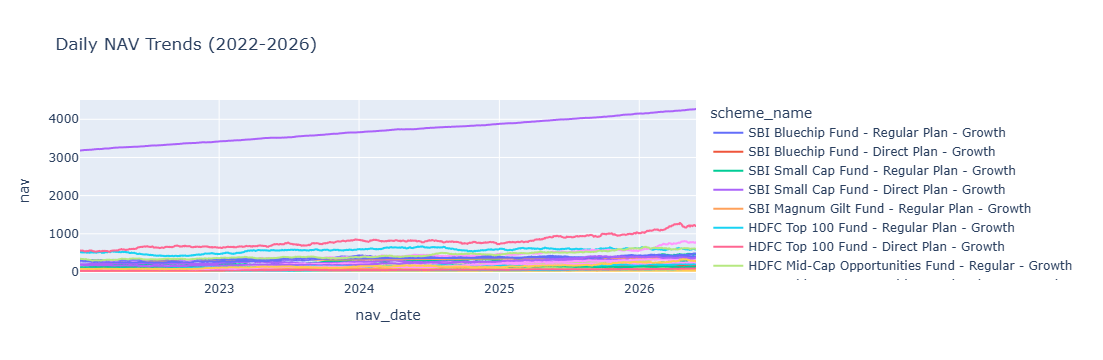

In [7]:
fig = px.line(
    nav_df,
    x='nav_date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trends (2022-2026)'
)

fig.show()

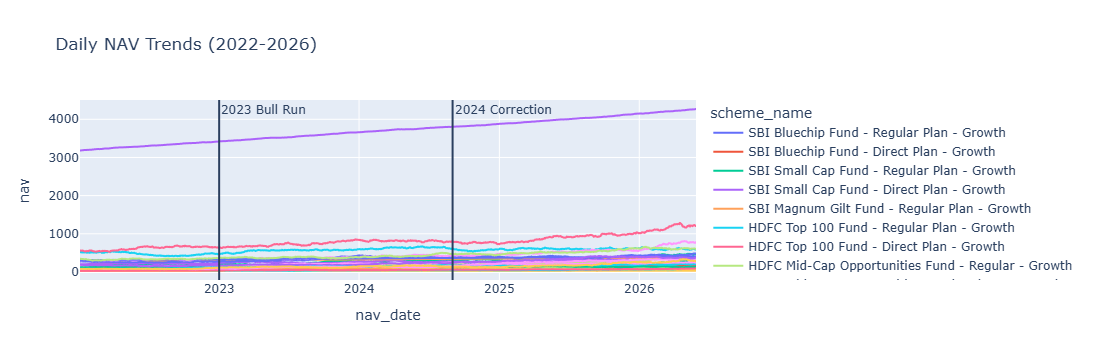

In [8]:
fig.add_vline(
    x='2023-01-01',
    annotation_text='2023 Bull Run'
)

fig.add_vline(
    x='2024-09-01',
    annotation_text='2024 Correction'
)

In [9]:
fig.write_image(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/nav_trend.png",
    width=1400,
    height=800
)

In [10]:
aum['year'] = pd.to_datetime(
    aum['aum_date']
).dt.year

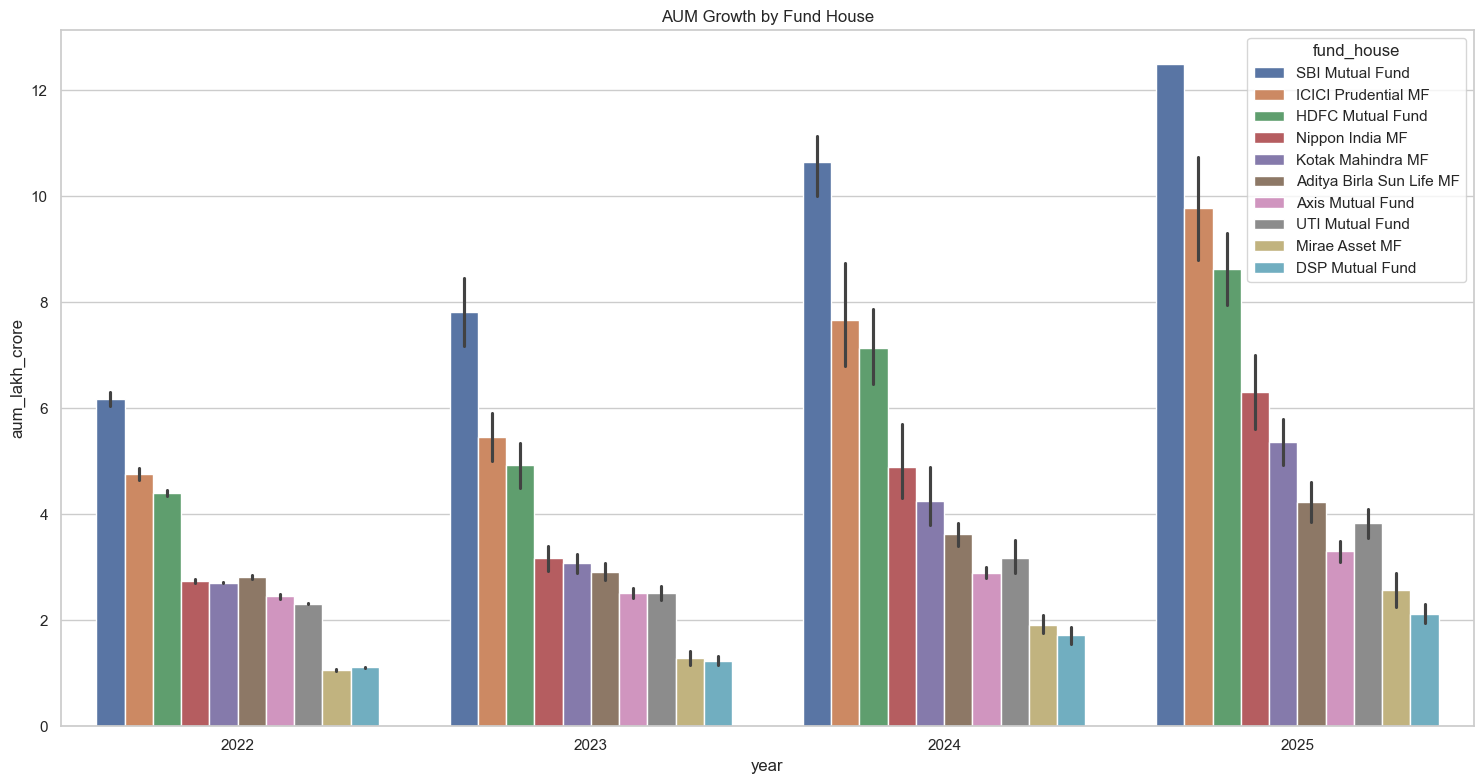

In [11]:
plt.figure(figsize=(15,8))

sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title(
    'AUM Growth by Fund House')

plt.tight_layout()

plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/AUM_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
aum.groupby('fund_house')['aum_lakh_crore'].max().sort_values(ascending=False)

fund_house
SBI Mutual Fund             12.50
ICICI Prudential MF         10.74
HDFC Mutual Fund             9.30
Nippon India MF              7.00
Kotak Mahindra MF            5.80
Aditya Birla Sun Life MF     4.60
UTI Mutual Fund              4.10
Axis Mutual Fund             3.50
Mirae Asset MF               2.90
DSP Mutual Fund              2.30
Name: aum_lakh_crore, dtype: float64

In [20]:
sip['month'] = pd.to_datetime(
    sip['month']
)

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflows'
)

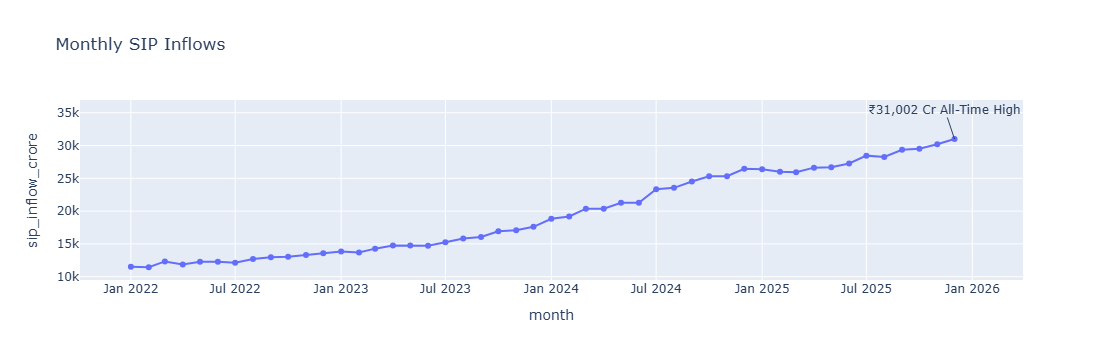

In [21]:
fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr All-Time High'
)


fig.show()

In [50]:
fig.write_image(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/SIP_Inflows.png"
)

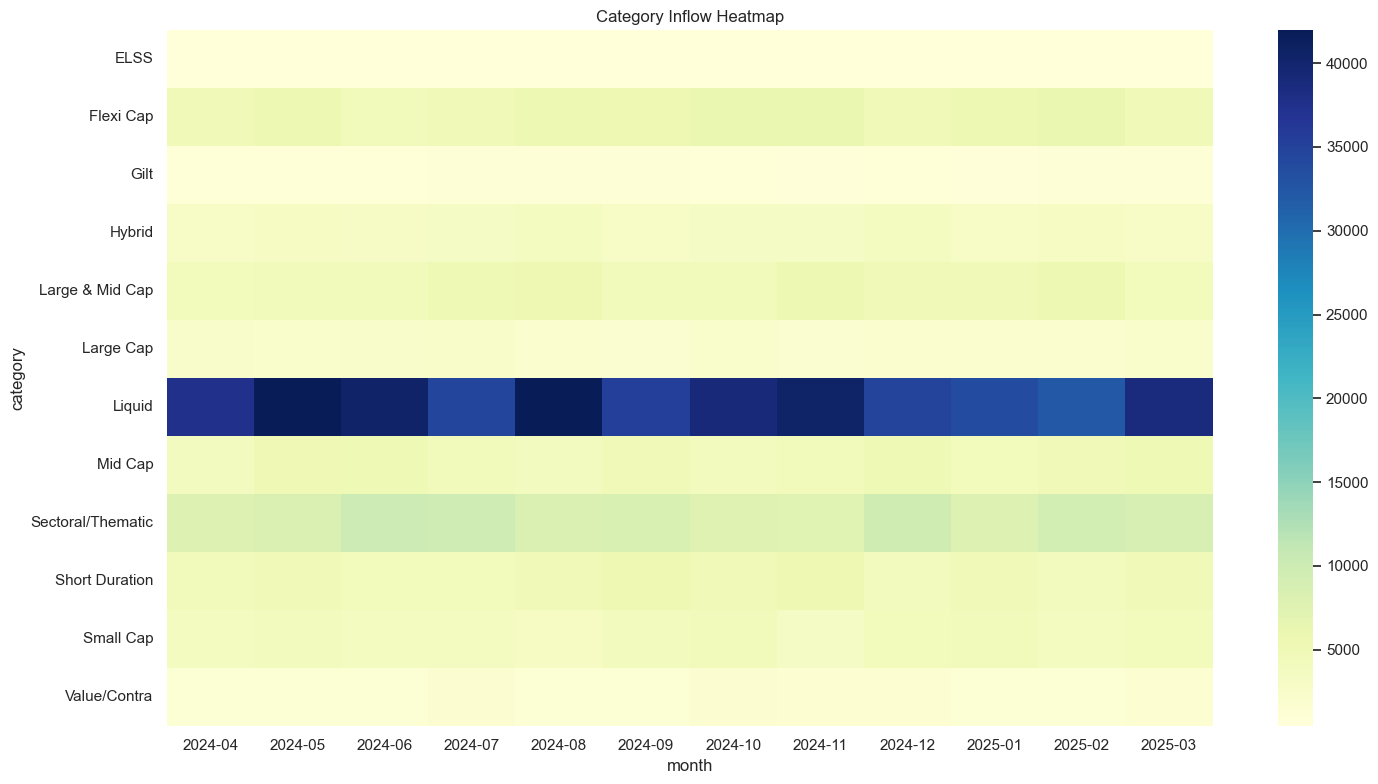

In [14]:
pivot = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title(
    'Category Inflow Heatmap'
)
plt.tight_layout()

plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/Category_Inflow_Heatmap.png",
    dpi=300
)

plt.show()

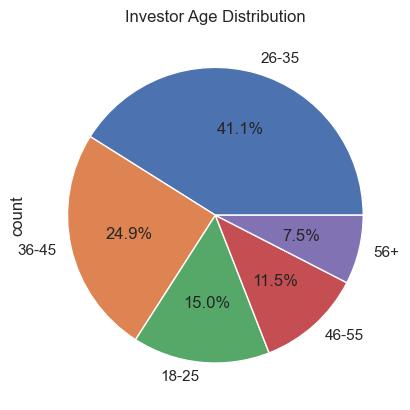

In [15]:
transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    'Investor Age Distribution'
)
plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/Age_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

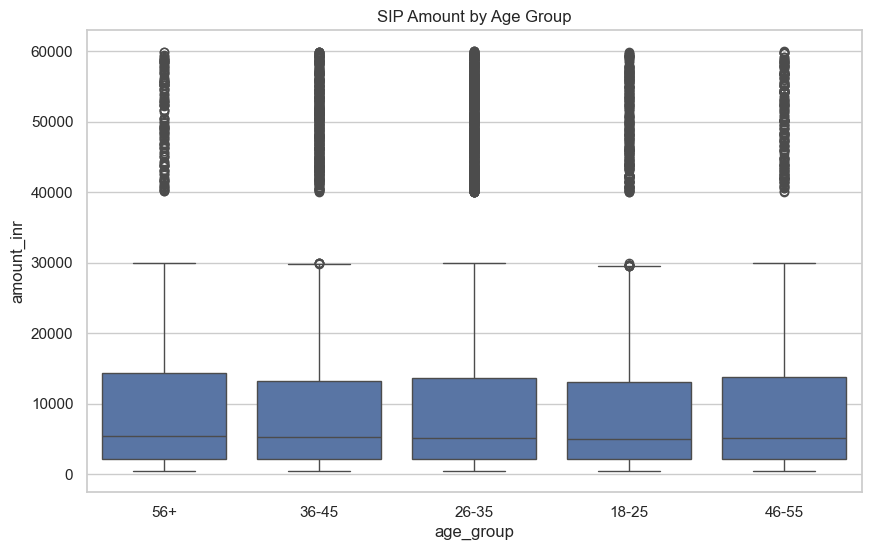

In [17]:
sip_tx = transactions[
    transactions['transaction_type']=='SIP'
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_tx,
    x='age_group',
    y='amount_inr'
)
plt.title("SIP Amount by Age Group")

plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/SIP_Amount_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

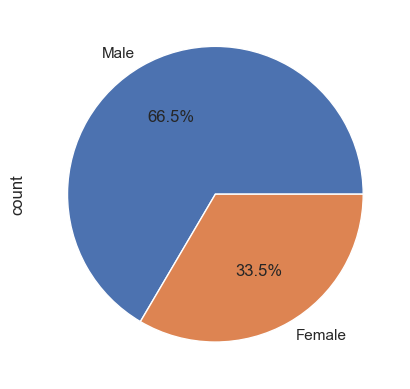

In [23]:
transactions['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/Gender_Split.png",
    dpi=300,
    bbox_inches="tight")

In [25]:
state_amount = (
    transactions.groupby('state')
    ['amount_inr']
    .sum()
    .sort_values()
)

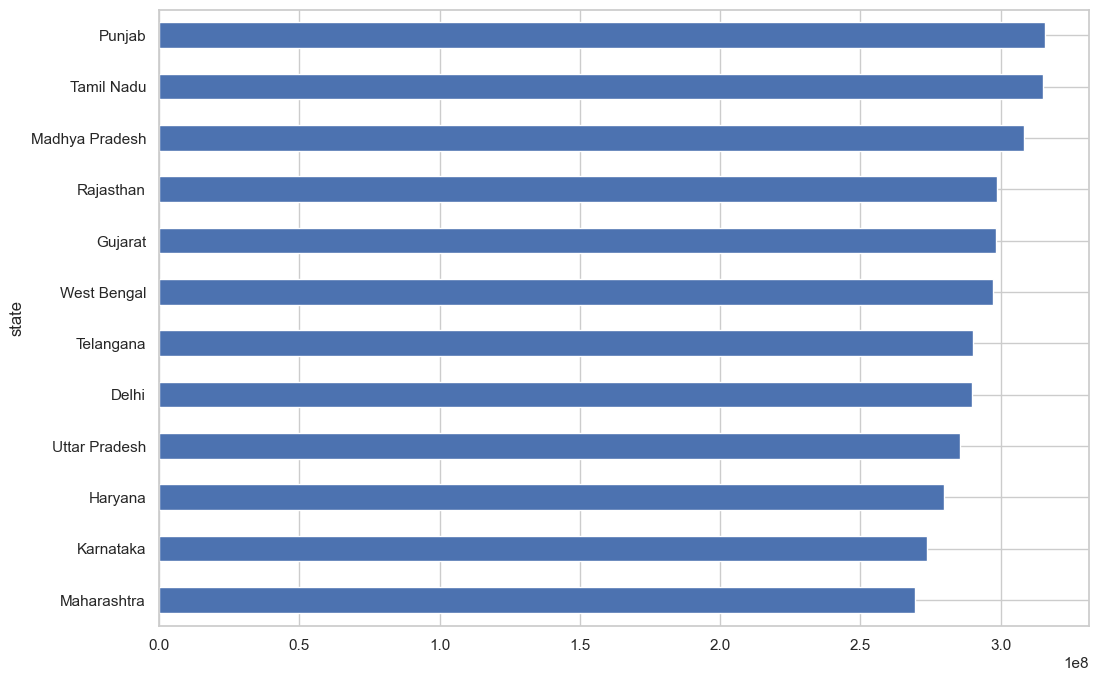

In [26]:
state_amount.plot(
    kind='barh',
    figsize=(12,8)
)
plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/State-wise_Investment.png",
    dpi=300,
    bbox_inches="tight")

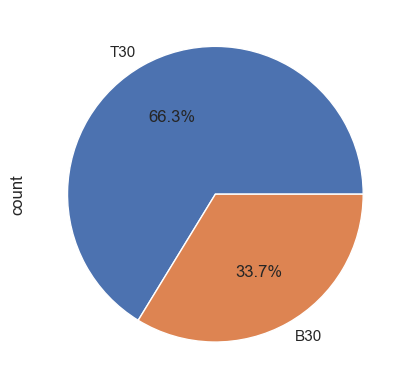

In [27]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/T30vsB30.png",
    dpi=300,
    bbox_inches="tight")

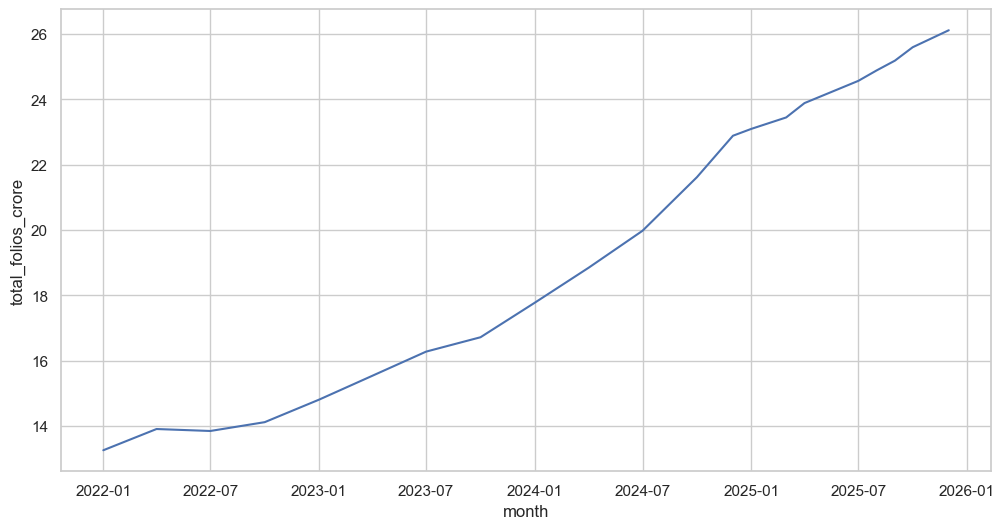

In [28]:
folio['month'] = pd.to_datetime(
    folio['month']
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x='month',
    y='total_folios_crore'
)
plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/Folio_Growth.png",
    dpi=300,
    bbox_inches="tight")

In [29]:
top10 = nav_df[
    nav_df['amfi_code'].isin(
        nav_df['amfi_code'].unique()[:10]
    )
]

In [30]:
returns = (
    top10
    .pivot(
        index='nav_date',
        columns='scheme_name',
        values='nav'
    )
    .pct_change()
)

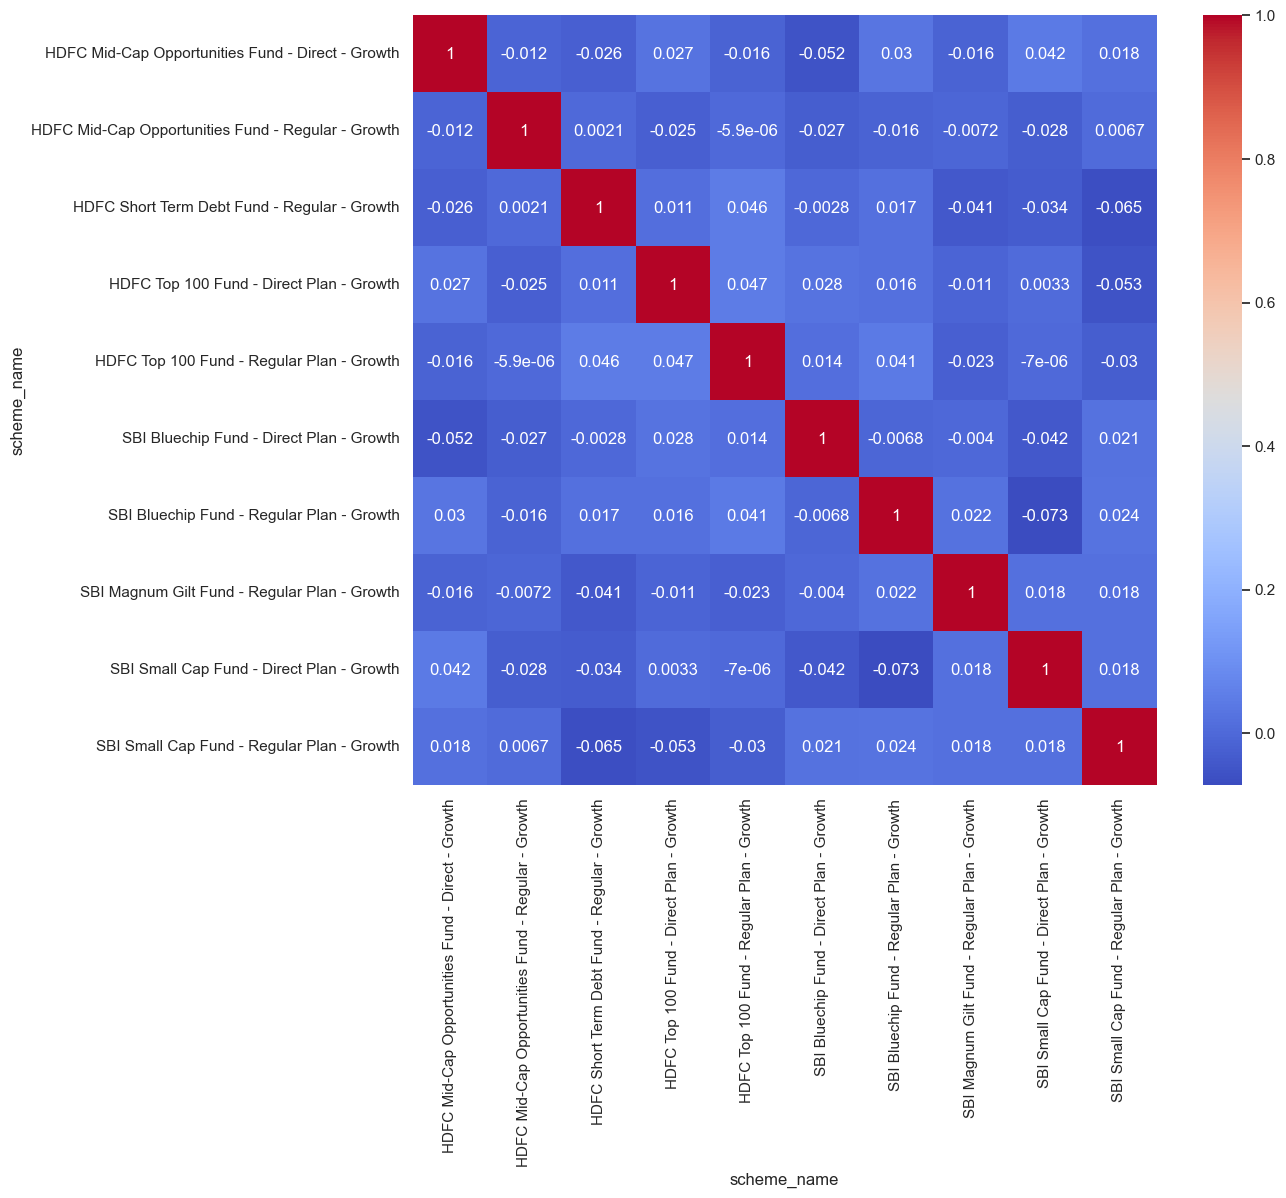

In [32]:
corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight")

In [33]:
sector = (
    portfolio.groupby('sector')
    ['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

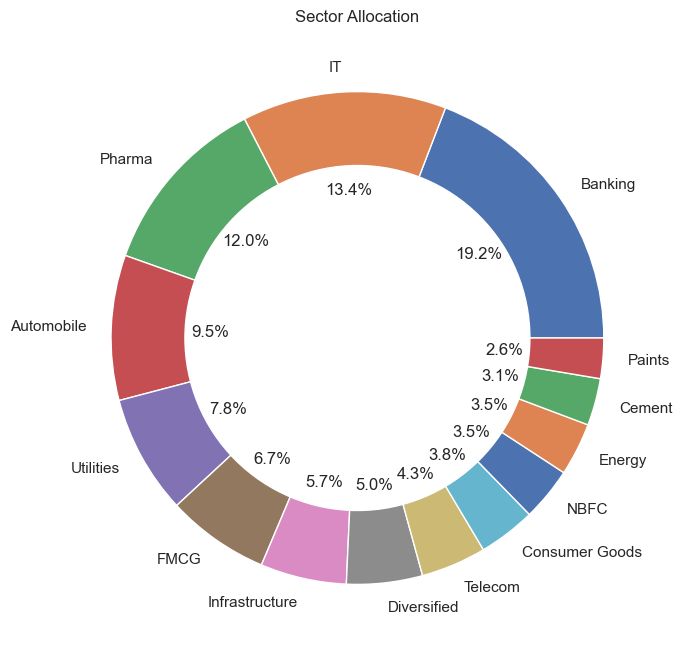

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

plt.gca().add_artist(
    centre_circle
)

plt.title(
    'Sector Allocation'
)

plt.show()
plt.savefig(
    "C:/Users/Admin/Desktop/Mutual_Fund_Analysis/Sector_Allocation_Donut.png",
    dpi=300,
    bbox_inches="tight")

## Key Findings

1. SBI Mutual Fund maintained the highest AUM across all reporting periods.
2. Industry SIP inflows reached an all-time high of ₹31,002 crore in Dec-2025.
3. Equity-oriented schemes showed stronger NAV appreciation than debt schemes.
4. Small-cap funds exhibited higher volatility but superior long-term returns.
5. T30 cities contributed a majority of transaction volume.
6. Investors aged 26–35 represented the largest investor segment.
7. SIP investments dominated transaction activity compared to lump-sum investments.
8. Banking and Financial Services represented the largest portfolio allocation.
9. Mutual fund folios nearly doubled between 2022 and 2025.
10. Large-cap funds showed stronger correlation with benchmark indices than thematic funds.